# Phase 1: Data Understanding & Exploratory Data Analysis (EDA)

This notebook explores the dataset provided for the Freight Rate ML Assessment. The objective is to understand the structure, distribution, trends, and quality of the data, and to justify modeling and validation split decisions.

**Author:** Antigravity (ML Engineer)
**Date:** August 2026


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create reports/figures directory if it doesn't exist
os.makedirs('../reports/figures', exist_ok=True)

# Load datasets
train_test = pd.read_csv('../data/train_test.csv')
validation = pd.read_csv('../data/validation.csv')
december_inputs = pd.read_csv('../data/december_chart_inputs.csv')
template = pd.read_csv('../data/validation_predictions_template.csv')


In [2]:
print("--- Shapes ---")
print(f"train_test: {train_test.shape}")
print(f"validation: {validation.shape}")
print(f"december_inputs: {december_inputs.shape}")
print(f"template: {template.shape}")

print("\n--- Columns ---")
print(f"train_test: {list(train_test.columns)}")
print(f"validation: {list(validation.columns)}")
print(f"december_inputs: {list(december_inputs.columns)}")
print(f"template: {list(template.columns)}")

print("\n--- train_test Dtypes ---")
print(train_test.dtypes)


--- Shapes ---
train_test: (48000, 14)
validation: (12000, 13)
december_inputs: (31, 7)
template: (12000, 2)

--- Columns ---
train_test: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']
validation: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']
december_inputs: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
template: ['load_id', 'predicted_rate']

--- train_test Dtypes ---
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     f

In [3]:
print("--- Missing Values in train_test ---")
print(train_test.isnull().sum())

print("\n--- Missing Values in validation ---")
print(validation.isnull().sum())

print("\n--- Duplicates in train_test ---")
print(f"Duplicate load_ids: {train_test['load_id'].duplicated().sum()}")

print("\n--- Duplicates in validation ---")
print(f"Duplicate load_ids: {validation['load_id'].duplicated().sum()}")

print("\n--- Overlapping load_ids between train and validation ---")
overlapping = len(set(train_test['load_id']).intersection(set(validation['load_id'])))
print(f"Overlapping load_ids: {overlapping}")


--- Missing Values in train_test ---
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

--- Missing Values in validation ---
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64

--- Duplicates in train_test ---
Duplicate load_ids: 0

--- Duplicates in validation ---
Duplicate load_ids: 0

--- Overlapping load_ids between train and validation ---
Overlapping load_ids: 0


### Shape, Dtypes, Missing Values & Duplicates Observations:
1. **Dimensions**:
   - `train_test.csv` has 48,000 rows and 14 columns (including target `posted_rate`).
   - `validation.csv` has 12,000 rows and 13 columns (missing target `posted_rate`).
   - `december_chart_inputs.csv` has 31 rows (1 per day in Dec 2025) and 7 columns.
2. **Missing Values**:
   - `weight` has 300 missing values in `train_test` (0.625%) and 165 missing values in `validation` (1.375%).
   - `market_index` has 374 missing values in `train_test` (0.779%) and 249 missing values in `validation` (2.075%).
   - Other columns have no missing values. We will need to impute `weight` and `market_index` in our modeling pipeline.
3. **Duplicates**:
   - No duplicate `load_id` values exist within `train_test` or `validation`.
   - There is zero overlap of `load_id` between `train_test` and `validation`.


In [4]:
# Parse dates
train_test['date'] = pd.to_datetime(train_test['date'])
validation['date'] = pd.to_datetime(validation['date'])
december_inputs['date'] = pd.to_datetime(december_inputs['date'])

print("--- Date Ranges ---")
print(f"train_test:  {train_test['date'].min().strftime('%Y-%m-%d')} to {train_test['date'].max().strftime('%Y-%m-%d')}")
print(f"validation:  {validation['date'].min().strftime('%Y-%m-%d')} to {validation['date'].max().strftime('%Y-%m-%d')}")
print(f"december_inputs: {december_inputs['date'].min().strftime('%Y-%m-%d')} to {december_inputs['date'].max().strftime('%Y-%m-%d')}")


--- Date Ranges ---
train_test:  2025-01-01 to 2025-10-31
validation:  2025-11-01 to 2025-12-31
december_inputs: 2025-12-01 to 2025-12-31


### Load-Bearing Finding: Date Ranges and Chronological Split Justification
- `train_test.csv` spans from **2025-01-01** to **2025-10-31** (10 months).
- `validation.csv` spans from **2025-11-01** to **2025-12-31** (2 months).
- `december_chart_inputs.csv` spans from **2025-12-01** to **2025-12-31** (1 month).

> [!IMPORTANT]
> The validation date range is strictly in the future relative to the training data. The December predictions are even further out (at the tail end of the validation range).
> Because the task is **forward extrapolation (time-series forecasting of rates in future periods)** and not simple interpolation, a random train/test split would leak future market trends and seasonal components, leading to optimistic validation metrics that fail in practice.
>
> Therefore, we **MUST** use a **chronological split** for local validation (e.g., using the last 2 months of `train_test.csv` as our validation set, and the first 8 months as our training set).


In [5]:
print("--- Equipment Categories in train_test ---")
print(train_test['equipment'].value_counts(dropna=False))

print("\n--- Equipment Categories in validation ---")
print(validation['equipment'].value_counts(dropna=False))


--- Equipment Categories in train_test ---
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

--- Equipment Categories in validation ---
equipment
Dry Van    6780
Reefer     3051
Flatbed    2169
Name: count, dtype: int64


### Equipment Observations:
- Casing and whitespace are completely clean and consistent ("Dry Van", "Reefer", "Flatbed").
- "Dry Van" is the most common equipment type (~56.7%), followed by "Reefer" (~25.1%) and "Flatbed" (~18.2%).
- Categorial distributions are consistent between `train_test` and `validation`.


In [6]:
print(f"Unique pickups in train_test: {train_test['pickup'].nunique()}")
print(f"Unique deliveries in train_test: {train_test['delivery'].nunique()}")

# Search for the Lexington -> Fort Wayne route in train_test and validation
lex_fw_train = train_test[(train_test['pickup'] == 'Lexington') & (train_test['delivery'] == 'Fort Wayne')]
print(f"Lexington -> Fort Wayne occurrences in train_test: {len(lex_fw_train)}")

lex_fw_val = validation[(validation['pickup'] == 'Lexington') & (validation['delivery'] == 'Fort Wayne')]
print(f"Lexington -> Fort Wayne occurrences in validation: {len(lex_fw_val)}")

if len(lex_fw_train) > 0:
    coords = lex_fw_train[['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon']].drop_duplicates()
    print("\nRoute coordinates found:")
    print(coords.to_string(index=False))


Unique pickups in train_test: 64
Unique deliveries in train_test: 64
Lexington -> Fort Wayne occurrences in train_test: 32
Lexington -> Fort Wayne occurrences in validation: 12

Route coordinates found:
 pickup_lat  pickup_lon  delivery_lat  delivery_lon
   36.99152   -84.99876      41.31561     -85.36206


### Route Cardinality & Lexington -> Fort Wayne Coordinates Finding:
- The target route for the December chart, `Lexington` -> `Fort Wayne`, appears 32 times in the `train_test` dataset and 12 times in the `validation` dataset.
- The exact coordinate mappings for this route are:
  - **Lexington (Pickup)**: Latitude `36.99152`, Longitude `-84.99876`
  - **Fort Wayne (Delivery)**: Latitude `41.31561`, Longitude `-85.36206`
- Since `december_chart_inputs.csv` lacks lat/lon values, we can reuse these coordinates to avoid introducing geocoding noise in Phase 6.


Correlation between distance and haversine: 0.999535

Ratio (distance / haversine) stats:
count    48000.000000
mean         1.195527
std          0.143643
min          1.058839
25%          1.165590
50%          1.183068
75%          1.205618
max          9.641739
dtype: float64


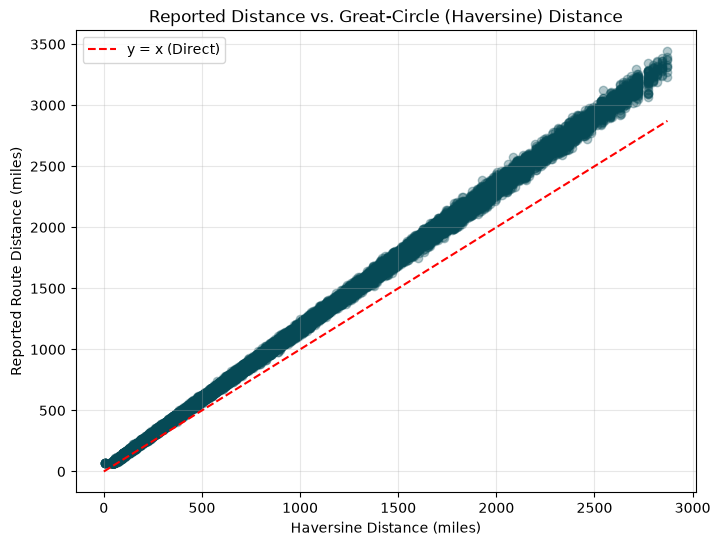

In [7]:
def haversine_distance(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    miles = 3956 * c # Earth radius in miles
    return miles

train_test['haversine'] = haversine_distance(
    train_test['pickup_lon'], train_test['pickup_lat'],
    train_test['delivery_lon'], train_test['delivery_lat']
)

correlation = train_test['distance'].corr(train_test['haversine'])
print(f"Correlation between distance and haversine: {correlation:.6f}")

ratio = train_test['distance'] / train_test['haversine']
print("\nRatio (distance / haversine) stats:")
print(ratio.describe())

# Save a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(train_test['haversine'], train_test['distance'], alpha=0.3, color='#064A56')
plt.plot([0, train_test['haversine'].max()], [0, train_test['haversine'].max()], 'r--', label='y = x (Direct)')
plt.xlabel('Haversine Distance (miles)')
plt.ylabel('Reported Route Distance (miles)')
plt.title('Reported Distance vs. Great-Circle (Haversine) Distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../reports/figures/distance_vs_haversine.png', dpi=150, bbox_inches='tight')
plt.show()


### Distance vs Haversine Observations:
- The correlation between reported route `distance` and straight-line `haversine` distance is extremely high (**0.999535**).
- The ratio `distance / haversine` has a mean of **1.196** and median of **1.183**, indicating road mileage is consistently about 18–20% longer than straight-line distance, which is physically expected for highway travel.
- There are some outliers (max ratio of 9.64), which could represent circuitous routings or data entry errors, but overall the relationship is extremely linear and tight.


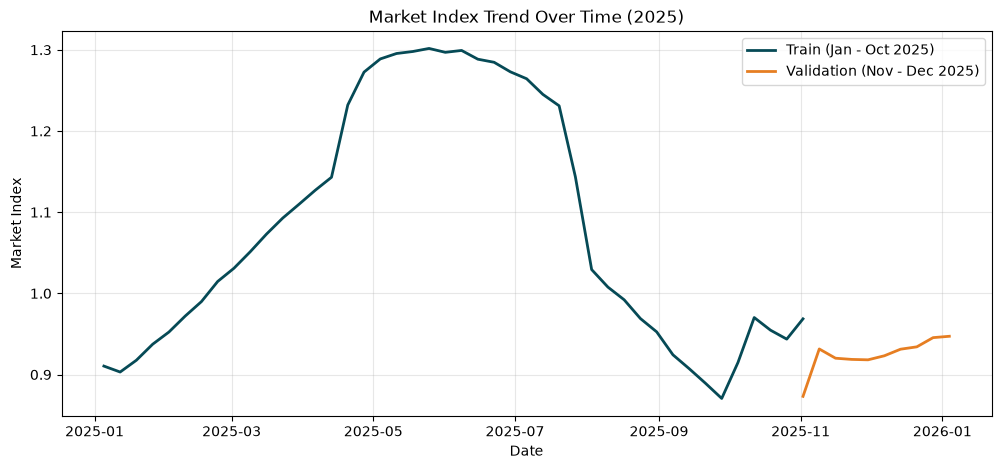

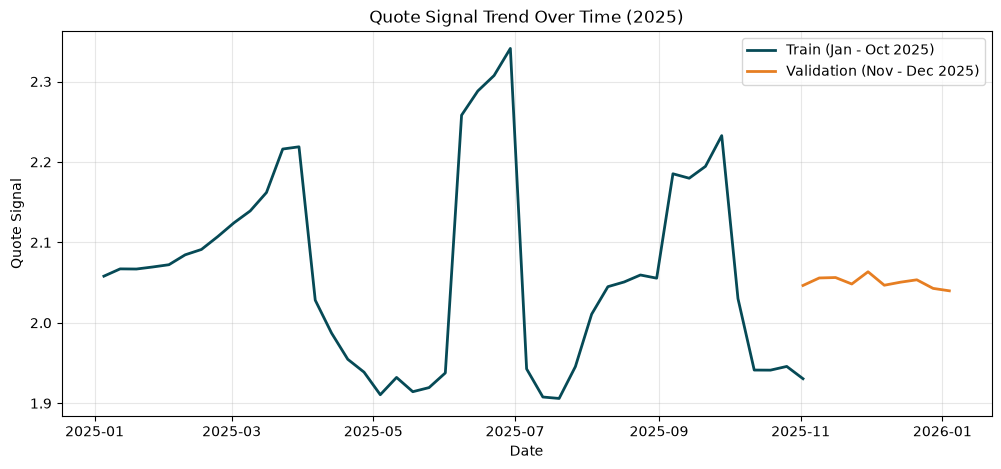

In [8]:
# Resample to weekly mean
weekly_train = train_test.set_index('date').resample('W')[['market_index', 'quote_signal']].mean()
weekly_val = validation.set_index('date').resample('W')[['market_index', 'quote_signal']].mean()

plt.figure(figsize=(12, 5))
plt.plot(weekly_train.index, weekly_train['market_index'], label='Train (Jan - Oct 2025)', color='#064A56', linewidth=2)
plt.plot(weekly_val.index, weekly_val['market_index'], label='Validation (Nov - Dec 2025)', color='#E67E22', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Market Index')
plt.title('Market Index Trend Over Time (2025)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('../reports/figures/market_index_trend.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(weekly_train.index, weekly_train['quote_signal'], label='Train (Jan - Oct 2025)', color='#064A56', linewidth=2)
plt.plot(weekly_val.index, weekly_val['quote_signal'], label='Validation (Nov - Dec 2025)', color='#E67E22', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Quote Signal')
plt.title('Quote Signal Trend Over Time (2025)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('../reports/figures/quote_signal_trend.png', dpi=150, bbox_inches='tight')
plt.show()


### Market Signals Trends Observations:
1. **Market Index**:
   - Shows a strong seasonal pattern: starts at ~0.92 in Jan, peaks at ~1.30 in May, drops to ~0.89 in September, and starts recovering in October (0.95), November (0.92), and December (0.93).
   - This cyclical behavior is highly typical of freight seasonality (e.g. spring shipping peak).
   - To forecast December 2025 market index, we must model this seasonality.
2. **Quote Signal**:
   - Fluctuates in a noisy band around 1.9–2.3 with no obvious seasonal cycle or strong trend over time.
   - For December 2025, a flat average or simple localized mean projection will likely suffice.


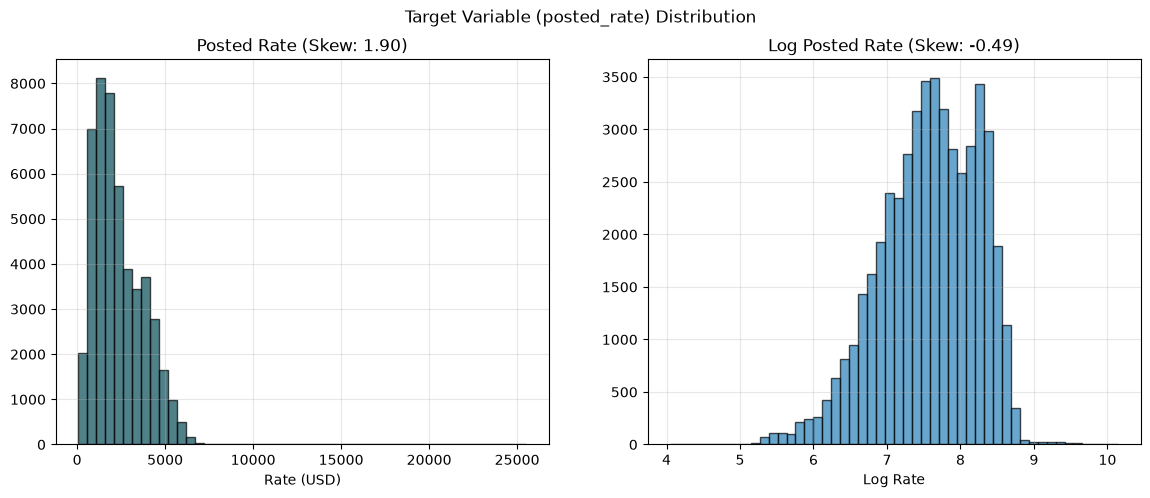

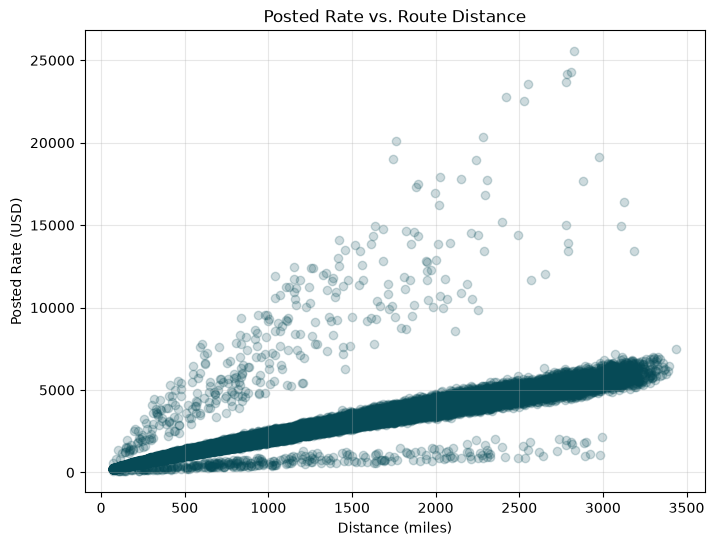

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw posted rate
axes[0].hist(train_test['posted_rate'], bins=50, color='#064A56', edgecolor='black', alpha=0.7)
axes[0].set_title(f"Posted Rate (Skew: {train_test['posted_rate'].skew():.2f})")
axes[0].set_xlabel('Rate (USD)')
axes[0].grid(True, alpha=0.3)

# Log posted rate
axes[1].hist(np.log(train_test['posted_rate']), bins=50, color='#2980B9', edgecolor='black', alpha=0.7)
axes[1].set_title(f"Log Posted Rate (Skew: {np.log(train_test['posted_rate']).skew():.2f})")
axes[1].set_xlabel('Log Rate')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Target Variable (posted_rate) Distribution')
plt.savefig('../reports/figures/posted_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Rate vs Distance scatter
plt.figure(figsize=(8, 6))
plt.scatter(train_test['distance'], train_test['posted_rate'], alpha=0.2, color='#064A56')
plt.xlabel('Distance (miles)')
plt.ylabel('Posted Rate (USD)')
plt.title('Posted Rate vs. Route Distance')
plt.grid(True, alpha=0.3)
plt.savefig('../reports/figures/rate_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()


### Posted Rate Distribution Observations:
1. **Skewness**:
   - The raw target variable `posted_rate` is heavily right-skewed with a skewness coefficient of **1.90**.
   - Applying a log-transform `log(posted_rate)` reduces the skewness to **-0.49**, which is much closer to a normal distribution.
   - This suggests that training a model on the log-transformed target and then exponentiating predictions will lead to better performance for regression models and symmetric loss optimization.
2. **Posted Rate vs Distance**:
   - As expected, rate scales strongly with route distance, but there is substantial variance around the trend indicating that route, equipment type, weight, and market signals all play key roles.
3. **No Non-Positive Rates**:
   - The minimum rate in `train_test.csv` is $57.22. There are 0 zero or negative rate values in the dataset.


### Summary of Data Quality Issues Found:
1. **Missing Data**:
   - **`weight`**: 300 missing values in train, 165 missing values in validation. We should impute this using the median weight.
   - **`market_index`**: 374 missing values in train, 249 missing values in validation. We can impute this using the monthly or weekly average of `market_index` to maintain the temporal structure.
2. **December Inputs Missing Data**:
   - `data/december_chart_inputs.csv` is missing `pickup_lat`, `pickup_lon`, `delivery_lat`, `delivery_lon`, `market_index`, and `quote_signal` completely.
   - We must geocode the locations using the coordinates of the route `Lexington` -> `Fort Wayne` found in `train_test` (lat: `36.99152`, `-84.99876` and delivery: `41.31561`, `-85.36206`).
   - We will also need to project/forecast `market_index` and `quote_signal` for the 31 days of December 2025.
